# 19 — Acoustic wave modelling with irregular free-surface topography (IBM)

This notebook demonstrates 2-D acoustic forward modelling in a medium with an
**irregular free surface** using the **Immersed Boundary Method** (IBM) of
Li et al. (2020, *J. Geophys. Eng.* 17, 643–660).

Standard finite-difference (FD) methods operate on a rectangular Cartesian grid,
so any non-flat surface must be approximated by a staircase of grid cells.
This staircase creates spurious diffraction waves at every "step" in the boundary.
The IBM avoids this by keeping the Cartesian grid but enforcing the free-surface
boundary condition $p = 0$ on the **exact** (non-grid-aligned) surface at every
time step via ghost-point correction.

## Governing equation

Variable-density acoustic wave equation (2nd order in time, non-staggered):

$$
\frac{1}{v^2} \frac{\partial^2 p}{\partial t^2}
= \nabla \cdot \left(\frac{1}{\rho} \nabla p\right) + s
$$

where $v(\mathbf{x})$ is P-wave velocity (km/s), $\rho(\mathbf{x})$ is density
(g/cm³), $p$ is pressure, and $s$ is the source term.

## IBM free-surface condition

Grid points strictly above the surface are **ghost points** whose values are
not physically meaningful after the FD update.  After each FD step the IBM
correction iterates:

$$
p^{\text{ghost}} \leftarrow -p^{\text{mirror}}
$$

where $p^{\text{mirror}}$ is the Lagrange-interpolated wavefield at the mirror
point of the ghost point through the surface.  When converged, $p = 0$ is
enforced exactly on the surface (to FD accuracy).

In [1]:
# NBVAL_IGNORE_OUTPUT
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

from examples.seismic.acoustic_topo.model import ModelTopo
from examples.seismic.acoustic_topo.wavesolver import AcousticTopoSolver
from examples.seismic.utils import AcquisitionGeometry

## Model setup: Gaussian hill topography

We build a 2 km × 2 km homogeneous medium ($v = 2$ km/s, $\rho = 1$ g/cm³)
with a Gaussian hill as the free surface:

$$
z_0(x) = z_{\text{flat}} + A \exp\!\left(-\frac{(x - x_0)^2}{2\sigma^2}\right)
$$

Grid points with physical depth $z < z_0(x)$ are ghost points;  all others
are physical-domain points where the wave equation is solved.

In [2]:
# NBVAL_IGNORE_OUTPUT
# ── grid parameters ─────────────────────────────────────────────────────────
nx, nz = 201, 201        # physical grid cells
dx, dz = 10., 10.        # grid spacing (metres)
nbl = 20                 # absorbing boundary layers

shape   = (nx, nz)
spacing = (dx, dz)
origin  = (0., 0.)

# ── constant medium ──────────────────────────────────────────────────────────
v   = 2.0 * np.ones(shape, dtype=np.float32)   # km/s
rho = 1.0 * np.ones(shape, dtype=np.float32)   # g/cm³

# ── Gaussian hill: z_flat=50 m, A=100 m, sigma=300 m, centred at x=1 km ────
x_phys = np.linspace(0., (nx - 1) * dx, nx)    # m
z_flat, A, x0, sigma = 350., 300., 1000., 200.
topo = z_flat - A * np.exp(-0.5 * ((x_phys - x0) / sigma)**2)

# ── build model ──────────────────────────────────────────────────────────────
model = ModelTopo(origin=origin, spacing=spacing, shape=shape,
                  space_order=4, v=v, rho=rho, topo=topo,
                  nbl=nbl, bcs='mask')

print(f"Physical grid     : {nx} × {nz} cells,  {dx:.0f} m spacing")
print(f"Ghost points      : {len(model.ghost_coords)}")
print(f"Critical Δt       : {model.critical_dt:.3f} ms")

# Ghost mask for the physical (unpadded) domain.
# IBM sets ghost values to −p_mirror (non-zero by design); we blank them in
# plots to display only the physically meaningful below-surface wavefield.
_is_ghost = model._build_surface_mask()[nbl:nbl + nx, 0:nz]  # (nx, nz) bool

Operator `initdamp` ran in 0.01 s


Physical grid     : 201 × 201 cells,  10 m spacing
Ghost points      : 5593
Critical Δt       : 2.773 ms


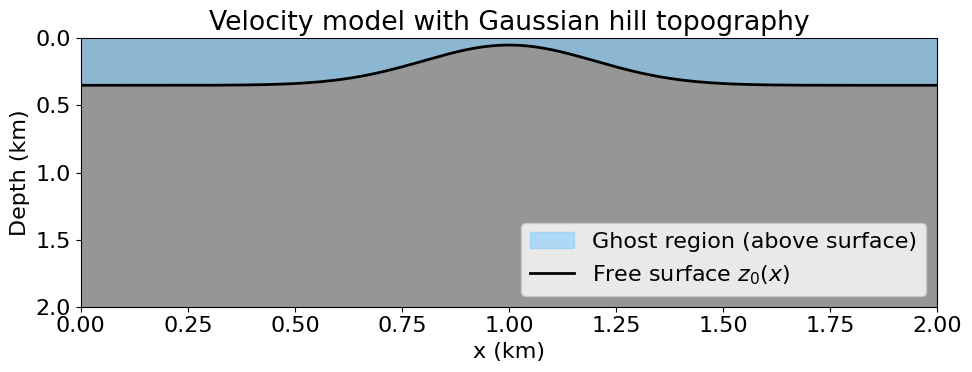

In [3]:
# NBVAL_IGNORE_OUTPUT
x_km = x_phys * 1e-3
z_km = np.linspace(0., (nz - 1) * dz * 1e-3, nz)

fig, ax = plt.subplots(figsize=(10, 4))
ax.imshow(v.T, cmap='Greys_r',
          extent=[x_km[0], x_km[-1], z_km[-1], z_km[0]],
          aspect='auto', vmin=1.8, vmax=2.2)
ax.fill_between(x_km, z_km[0], topo * 1e-3,
                color='lightskyblue', alpha=0.6, label='Ghost region (above surface)')
ax.plot(x_km, topo * 1e-3, 'k-', lw=2, label='Free surface $z_0(x)$')
ax.set_xlabel('x (km)')
ax.set_ylabel('Depth (km)')
ax.set_title('Velocity model with Gaussian hill topography')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Acquisition geometry

A single **Ricker-wavelet source** ($f_0 = 25$ Hz) is placed below the hill peak,
and a dense **receiver line** spans the full model at the same depth.

In [4]:
# NBVAL_IGNORE_OUTPUT
src_x, src_z = 1000., 500.                      # m — below the 150 m hill peak

rec_x = np.linspace(0., (nx - 1) * dx, nx)      # m
rec_z = 200. * np.ones(nx)

src_pos = np.array([[src_x, src_z]])
rec_pos = np.column_stack([rec_x, rec_z])

t0, tn = 0., 600.                               # ms
geom = AcquisitionGeometry(model, rec_pos, src_pos,
                           t0=t0, tn=tn, src_type='Ricker', f0=0.025)

print(f"Time steps : {geom.nt},  dt = {geom.dt:.3f} ms,  tn = {tn:.0f} ms")

Time steps : 218,  dt = 2.773 ms,  tn = 600 ms


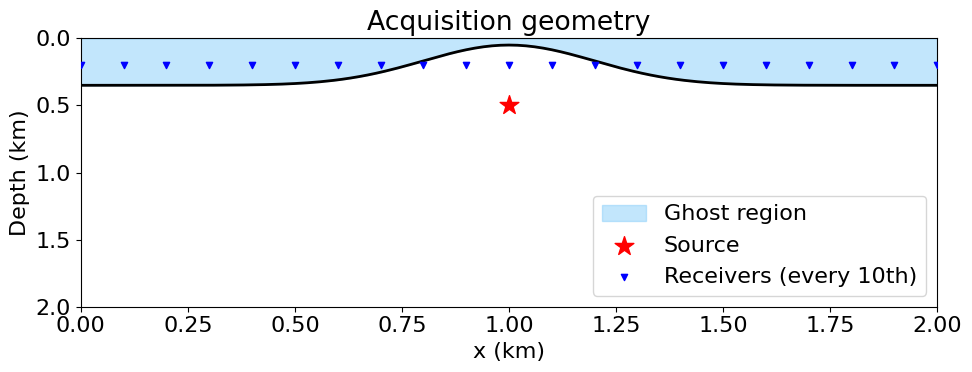

In [5]:
# NBVAL_IGNORE_OUTPUT
fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(x_km, z_km[0], topo * 1e-3,
                color='lightskyblue', alpha=0.5, label='Ghost region')
ax.plot(x_km, topo * 1e-3, 'k-', lw=2)
ax.scatter([src_x * 1e-3], [src_z * 1e-3], c='red', s=200, zorder=5,
           marker='*', label='Source')
ax.scatter(rec_x[::10] * 1e-3, rec_z[::10] * 1e-3, c='blue', s=20,
           marker='v', zorder=5, label='Receivers (every 10th)')
ax.set_xlim(x_km[0], x_km[-1])
ax.set_ylim(z_km[-1], z_km[0])
ax.set_xlabel('x (km)')
ax.set_ylabel('Depth (km)')
ax.set_title('Acquisition geometry')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## IBM forward propagation

The time loop runs manually: for each step $t$,
1. the Devito FD operator advances the pressure field by one step, then
2. `ibm_step` iterates the ghost-point correction until convergence.

We use `save=True` to retain the full time history for snapshot visualisation.

In [6]:
# NBVAL_IGNORE_OUTPUT
solver = AcousticTopoSolver(model, geom, space_order=4)
rec_ibm, p_ibm, summary = solver.forward(save=True)
print(summary)

Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
O

PerformanceSummary([(PerfKey(name='section0', rank=None), PerfEntry(time=4.6e-05, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[])), (PerfKey(name='section1', rank=None), PerfEntry(time=1e-06, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[])), (PerfKey(name='section2', rank=None), PerfEntry(time=1e-06, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[]))])


### Pressure snapshots

Snapshots at three time steps show the downgoing wave, the reflection from the
Gaussian hill, and the reflected wavefront propagating back into the medium.
The wavefield is identically zero above the free surface (blue/white region),
confirming that the IBM boundary condition $p = 0$ is enforced.

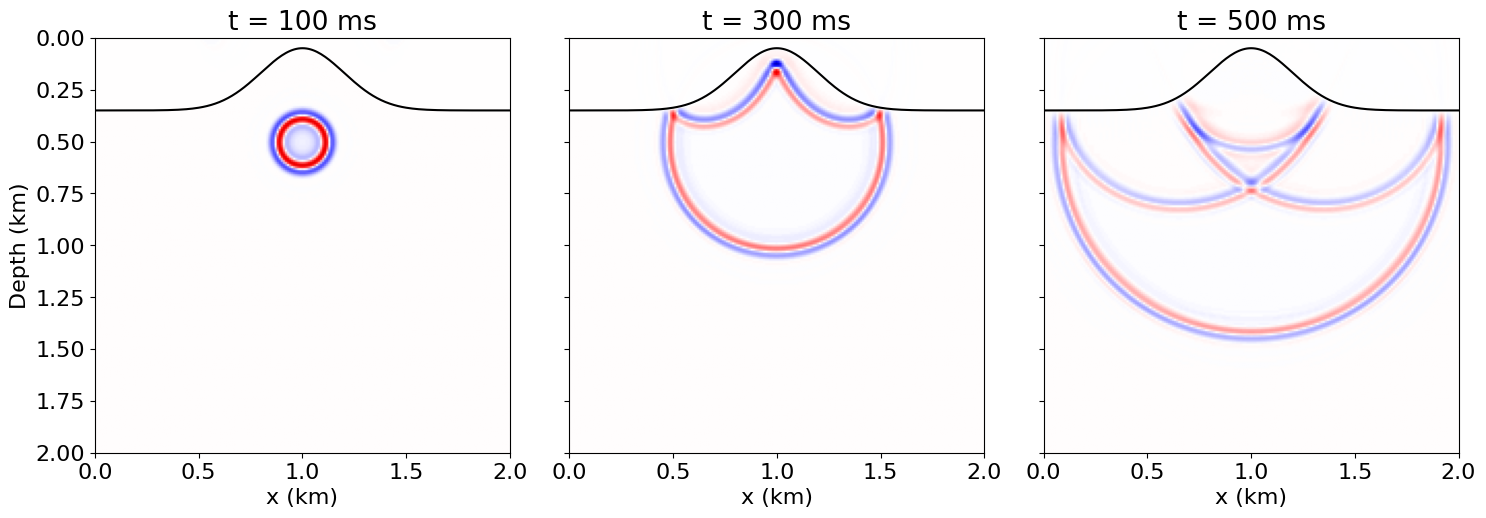

In [18]:
# NBVAL_IGNORE_OUTPUT
dt = geom.dt
snap_times_ms = [100., 300., 500.]
snap_indices  = [int(t / dt) for t in snap_times_ms]

p_arr = np.asarray(p_ibm.data)        # (nt, nx_pad, nz_pad)
vmax  = 0.3 * float(np.max(np.abs(p_arr)))

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
ext = [x_km[0], x_km[-1], z_km[-1], z_km[0]]

for ax, t_ms, t_idx in zip(axes, snap_times_ms, snap_indices):
    snap = p_arr[t_idx, nbl:nbl + nx, 0:nz].T    # (nz, nx) — depth on row axis
    im = ax.imshow(snap, cmap='seismic', vmin=-vmax, vmax=vmax,
                   extent=ext, aspect='auto')
    ax.fill_between(x_km, z_km[0], topo * 1e-3,
                    color='white', alpha=0.99)
    ax.plot(x_km, topo * 1e-3, 'k-', lw=1.5)
    ax.set_title(f't = {t_ms:.0f} ms')
    ax.set_xlabel('x (km)')
    ax.set_aspect('equal')

axes[0].set_ylabel('Depth (km)')
# fig.colorbar(im, ax=axes, shrink=0.8, label='Pressure (a.u.)')
# plt.suptitle('IBM pressure field', y=1.01)
plt.tight_layout()
plt.show()

### Shot record

The shot record (receiver pressure vs. time) shows the direct wave and the
**curved reflection** from the Gaussian hill.  The hill acts as a concave
reflector, focusing energy near the source offset.

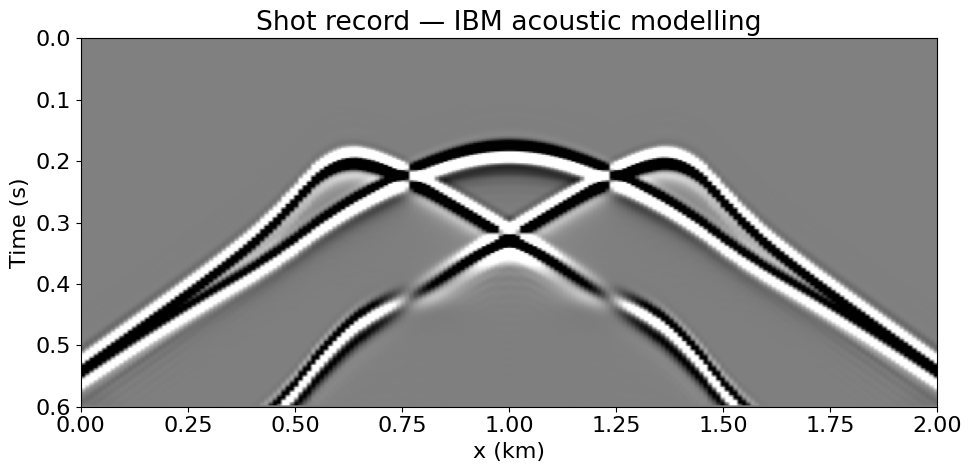

In [8]:
# NBVAL_IGNORE_OUTPUT
rec_data = np.asarray(rec_ibm.data)              # (nt, nrec)
scale    = np.max(np.abs(rec_data)) / 10.
extent_r = [x_km[0], x_km[-1], tn * 1e-3, t0]  # x in km, t in s

fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(rec_data, vmin=-scale, vmax=scale, cmap='gray',
          extent=extent_r, aspect='auto')
ax.set_xlabel('x (km)')
ax.set_ylabel('Time (s)')
ax.set_title('Shot record — IBM acoustic modelling')
plt.tight_layout()
plt.show()

## Effect of the IBM ghost-point correction

To appreciate what the IBM correction achieves, we run the same propagation
with `ibm_n_iter=0` — the FD update proceeds without ever correcting the ghost
points.  Ghost-point values are then whatever the stencil computes using the
Cartesian (non-physical) discretisation above the surface.

In contrast to the IBM result, the uncorrected simulation **leaks energy into
the ghost region** and fails to enforce $p = 0$ at the surface.

In [9]:
# NBVAL_IGNORE_OUTPUT
# The FD operator is already compiled; only the Python IBM loop is skipped.
rec_noibm, p_noibm, _ = solver.forward(save=True, ibm_n_iter=0)

Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
Operator `ForwardTopo` ran in 0.01 s
O

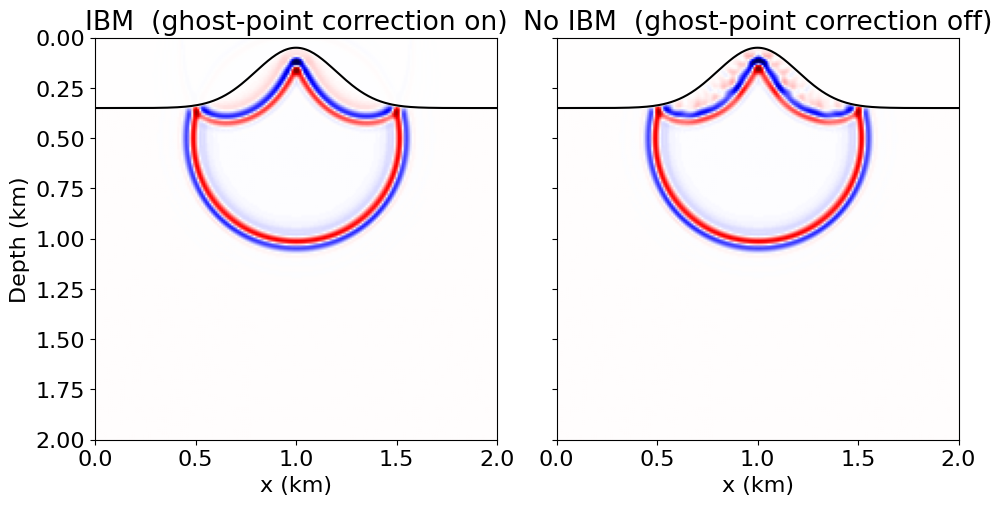

In [17]:
# NBVAL_IGNORE_OUTPUT
t_cmp_ms  = 300.
t_cmp_idx = int(t_cmp_ms / dt)
p_noibm_arr = np.asarray(p_noibm.data)

fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

for ax, p_arr_i, label in [
        (axes[0], p_arr,       'IBM  (ghost-point correction on)'),
        (axes[1], p_noibm_arr, 'No IBM  (ghost-point correction off)')]:

    snap = p_arr_i[t_cmp_idx, nbl:nbl + nx, 0:nz].T
    im = ax.imshow(snap*2, cmap='seismic', vmin=-vmax, vmax=vmax,
                   extent=ext, aspect='auto')
    ax.fill_between(x_km, z_km[0], topo * 1e-3,
                    color='white', alpha=0.99)
    ax.plot(x_km, topo * 1e-3, 'k-', lw=1.5)
    ax.set_title(label)
    ax.set_xlabel('x (km)')
    ax.set_aspect('equal')

axes[0].set_ylabel('Depth (km)')
# fig.colorbar(im, ax=axes, shrink=0.8, label='Pressure (a.u.)')
# plt.suptitle(f't = {t_cmp_ms:.0f} ms', y=1.01)
plt.tight_layout()
plt.show()

The right panel shows that without correction the wavefield propagates unimpeded
into the ghost region — the free surface is transparent and the boundary
condition $p = 0$ is violated.  The IBM (left panel) suppresses this leakage
and produces a physically correct reflection from the curved surface.

## Summary

| Feature | Value |
|---------|-------|
| Governing equation | Variable-density acoustic, 2nd order in time |
| Free surface | IBM — exact (non-staircase) with iterative ghost correction |
| Source | Ricker wavelet, $f_0 = 25$ Hz |
| Velocity | 2.0 km/s (homogeneous) |
| Grid | 201 × 201 cells, 10 m spacing |
| IBM iterations / step | up to 20 (convergence $< 10^{-6}$) |

## Reference

Li, J., Cao, J., Liu, Y., & Ren, Z. (2020).  A stable and efficient approach of
the inverse interpolation method for irregular surface seismic forward modeling.
*Journal of Geophysical Engineering*, 17(4), 643–660.
https://doi.org/10.1093/jge/gxaa019